In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Datasets/BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df['Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [4]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [6]:
print(df['Education_Level'].unique())
print(df['Marital_Status'].unique())
print(df['Income_Category'].unique())
print(df['Card_Category'].unique())
print(df['Gender'].unique())

['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
['Married' 'Single' 'Unknown' 'Divorced']
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
['Blue' 'Gold' 'Silver' 'Platinum']
['M' 'F']


In [7]:
df['Attrition_Flag'].value_counts()


Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [8]:
df['Attrition_Flag'] = (
    df['Attrition_Flag']
    .str.strip()         
    .str.lower()
    .map({
        'existing customer': 1,
        'attrited customer': 0
    })
)
df['Attrition_Flag']


0        1
1        1
2        1
3        1
4        1
        ..
10122    1
10123    0
10124    0
10125    0
10126    0
Name: Attrition_Flag, Length: 10127, dtype: int64

In [9]:
df=df.drop(columns=['CLIENTNUM'])
X=df.drop(columns=['Attrition_Flag'])
y=df['Attrition_Flag']


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [11]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
cat_cols = [
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category',
    'Gender'
]
X_train = ohe.fit_transform(X_train[cat_cols])
X_test  = ohe.transform(X_test[cat_cols])




In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train)
X_test_final  = scaler.transform(X_test)

In [13]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [14]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(3, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            57 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [25]:
history=model.fit(X_train_final,y_train,epochs=15,validation_split=0.2,)

Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8383 - loss: 0.4397 - val_accuracy: 0.8445 - val_loss: 0.4322
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.4397 - val_accuracy: 0.8445 - val_loss: 0.4322
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.4397 - val_accuracy: 0.8445 - val_loss: 0.4322
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8383 - loss: 0.4397 - val_accuracy: 0.8445 - val_loss: 0.4322
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.4396 - val_accuracy: 0.8445 - val_loss: 0.4322
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8383 - loss: 0.4396 - val_accuracy: 0.8445 - val_loss: 0.4323
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.4396 - val_accuracy: 0.8445 - val_loss: 0.4323
Epoch 8/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8383 - loss: 0.4396 - val_accuracy: 0.

In [19]:
model.layers[0].get_weights()

[array([[-0.2830289 ,  0.2187018 , -0.25710183],
        [ 0.09007681,  0.08147556,  0.06511836],
        [ 0.284677  , -0.23951286, -0.06546821],
        [-0.16630341,  0.12186799, -0.09868954],
        [-0.08105496, -0.05591637,  0.37778726],
        [-0.20466112,  0.16708612,  0.25184402],
        [ 0.1492526 , -0.13267317,  0.4764322 ],
        [-0.27257535, -0.3124081 ,  0.38826504],
        [-0.21403562,  0.08179552,  0.2819339 ],
        [ 0.21184322,  0.28458124,  0.24224341],
        [ 0.09864963, -0.31358695, -0.19604932],
        [-0.06760526, -0.16921572, -0.24898656],
        [ 0.19629776,  0.0349406 , -0.16674997],
        [ 0.12197277, -0.05985734, -0.0649817 ],
        [-0.03754414,  0.3976406 ,  0.14097737],
        [-1.3674989 ,  1.1871378 , -0.43093088],
        [ 0.54738176,  0.5406154 ,  0.26656908],
        [ 0.38254154, -0.24517925,  0.5015176 ]], dtype=float32),
 array([ 0.91149753, -0.6587358 ,  0.12513903], dtype=float32)]

In [24]:

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
y_pred_binary = (y_pred >= 0.5).astype(int)

accuracy_score(y_test, y_pred_binary)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step


0.8385982230997039

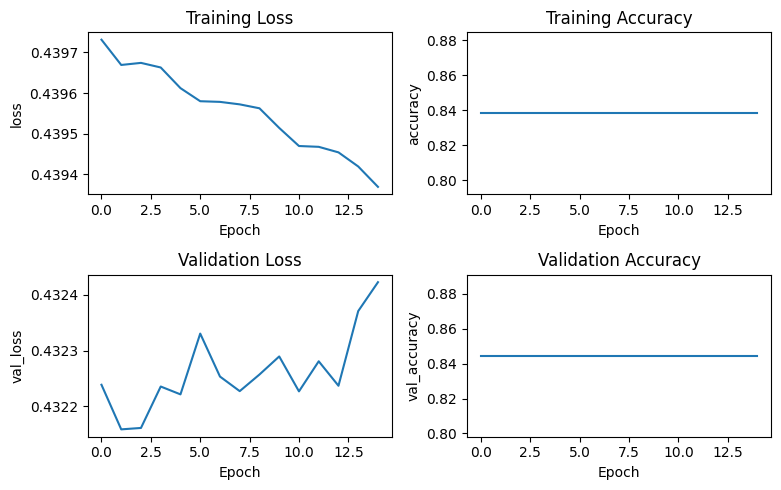

In [26]:

metrics = [
    "loss",
    "accuracy",
    "val_loss",
    "val_accuracy"
]

titles = [
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy"
]

fig, axs = plt.subplots(2, 2, figsize=(8, 5))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.plot(history.history[metrics[i]])
    ax.set_title(titles[i])
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metrics[i])

plt.tight_layout()
plt.show()


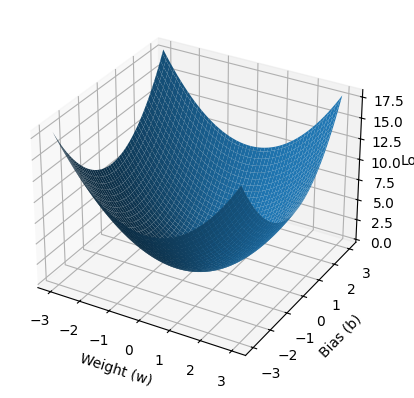

In [3]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-3,3,100)
b = np.linspace(-3,3,100)
W, B = np.meshgrid(w, b)

L = W**2 + B**2# Example convex loss

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, L)
ax.set_xlabel("Weight (w)")
ax.set_ylabel("Bias (b)")
ax.set_zlabel("Loss")
plt.show()



In [4]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Contour(
        z=L,
        x=w,
        y=b,
        contours=dict(showlabels=True)
    )
)

fig.update_layout(
    title="Interactive Loss Contour",
    xaxis_title="Weight",
    yaxis_title="Bias"
)

fig.show()
